In [1]:
import numpy as np
from matplotlib import pyplot as plt

my_figsize = [10, 8]
my_fontsize = 75

NUM_BINS = 50000

num_buckets = 600000-1

loads = ['0.1', '0.25', '0.5', '0.75', '1']
loads = ['0.75']

colors = ["firebrick", "firebrick", "darkblue", "forestgreen", "royalblue", "darkorchid", "darkblue", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred"]
linestyles = ['solid', 'dashdot', 'dashed', 'dotted']
def freq_array_to_cdf(freq_array):
    # 将频率数组转换为概率数组
    prob_array = freq_array / np.sum(freq_array)

    # 计算累积和
    cdf_array = np.cumsum(prob_array)

    return cdf_array

def find_last_nonzero(arr):
    for i in range(len(arr) - 1, 0, -1):
        if arr[i] > 0.1:
            return i
    return None

def load_and_draw(start, end, filename, iii, label):
    src_delays = np.zeros(num_buckets)
    for index in range(start, end):
            # draws/DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_0.1/packet_rough_delays_0.txt
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/packet_rough_delays_{0}.txt".format(index) 
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_TEST/packet_rough_delays_{0}.txt".format(index) 
        delay_filename=filename.format(index)
        tmp = np.loadtxt(delay_filename)
        src_delays += tmp[:num_buckets]
        # print(find_last_nonzero(tmp[:num_buckets]))
    # src_delays = np.trim_zeros(src_delays, 'b')
    np.set_printoptions(threshold=np.inf)
    last_non_zero = find_last_nonzero(src_delays)
    # print(last_non_zero)
    # print(src_delays[num_buckets-10:num_buckets])
    src_delays = src_delays[:last_non_zero]
    print("max SRC packet delay: ", len(src_delays), "us")
    # print(src_delays)
    cdf = freq_array_to_cdf(src_delays)        
    # plt.plot(np.arange(0, cdf[0:show_nums])/1e3, cdf[0:show_nums], linestyle='solid', linewidth=5, color = 'firebrick', label="load="+load)
    # plt.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)
    ax.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)

def src_packet_delay(filename1, filename2, filename3):
    for i, load in enumerate(loads):
        # plt.subplots(figsize=(10, 8))
        # fct = np.loadtxt("../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/FCT.txt")
        
        # load_and_draw(0, 7, filename1, 0, "ESN-OSUB")
        load_and_draw(0, 7, filename1, 0, "Flashpod (endhost)")
        if filename2 != '':
            load_and_draw(10, 17, filename2, 1, "Flashpod (inter node)")
        if filename3 != '':
            load_and_draw(0, 7, filename3, 2, "ESN-OSUB (endhost)")
        # load_and_draw(3, 5, filename, 2, "100KB~10MB")
        # load_and_draw(5, 7, filename, 3, "> 10MB")
        
        plt.xlabel("Delay (ms)", fontsize=my_fontsize)
        plt.ylabel("CDF", fontsize=my_fontsize)
        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)
        # plt.xlim(0, 0.)
        plt.legend(loc="lower right", fontsize=50)
        plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.9)
        # plt.xscale('log')
        # plt.title("Source Packet Delay", fontsize=my_fontsize)
        # plt.title("Network Delay", fontsize=my_fontsize)

def core_packet_delay(filename):
    for i, load in enumerate(loads):
        plt.subplots(figsize=(10, 8))
        # fct = np.loadtxt("../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/FCT.txt")
        src_delays = np.zeros(num_buckets)
        load_and_draw(10, 13, filename, 1, "< 100KB", )
        load_and_draw(13, 15, filename, 2, "100KB~10MB")
        load_and_draw(15, 17, filename, 3, "> 10MB")
        
        plt.xlabel("Delay (ms)", fontsize=my_fontsize)
        plt.ylabel("CDF", fontsize=my_fontsize)
        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)
        # plt.xlim(0, 0.5)
        plt.xscale('log')
        plt.legend(loc="upper left", fontsize=20)
        plt.title("Core Packet Delay", fontsize=my_fontsize)


max SRC packet delay:  110273 us
max SRC packet delay:  10395 us
max SRC packet delay:  418080 us


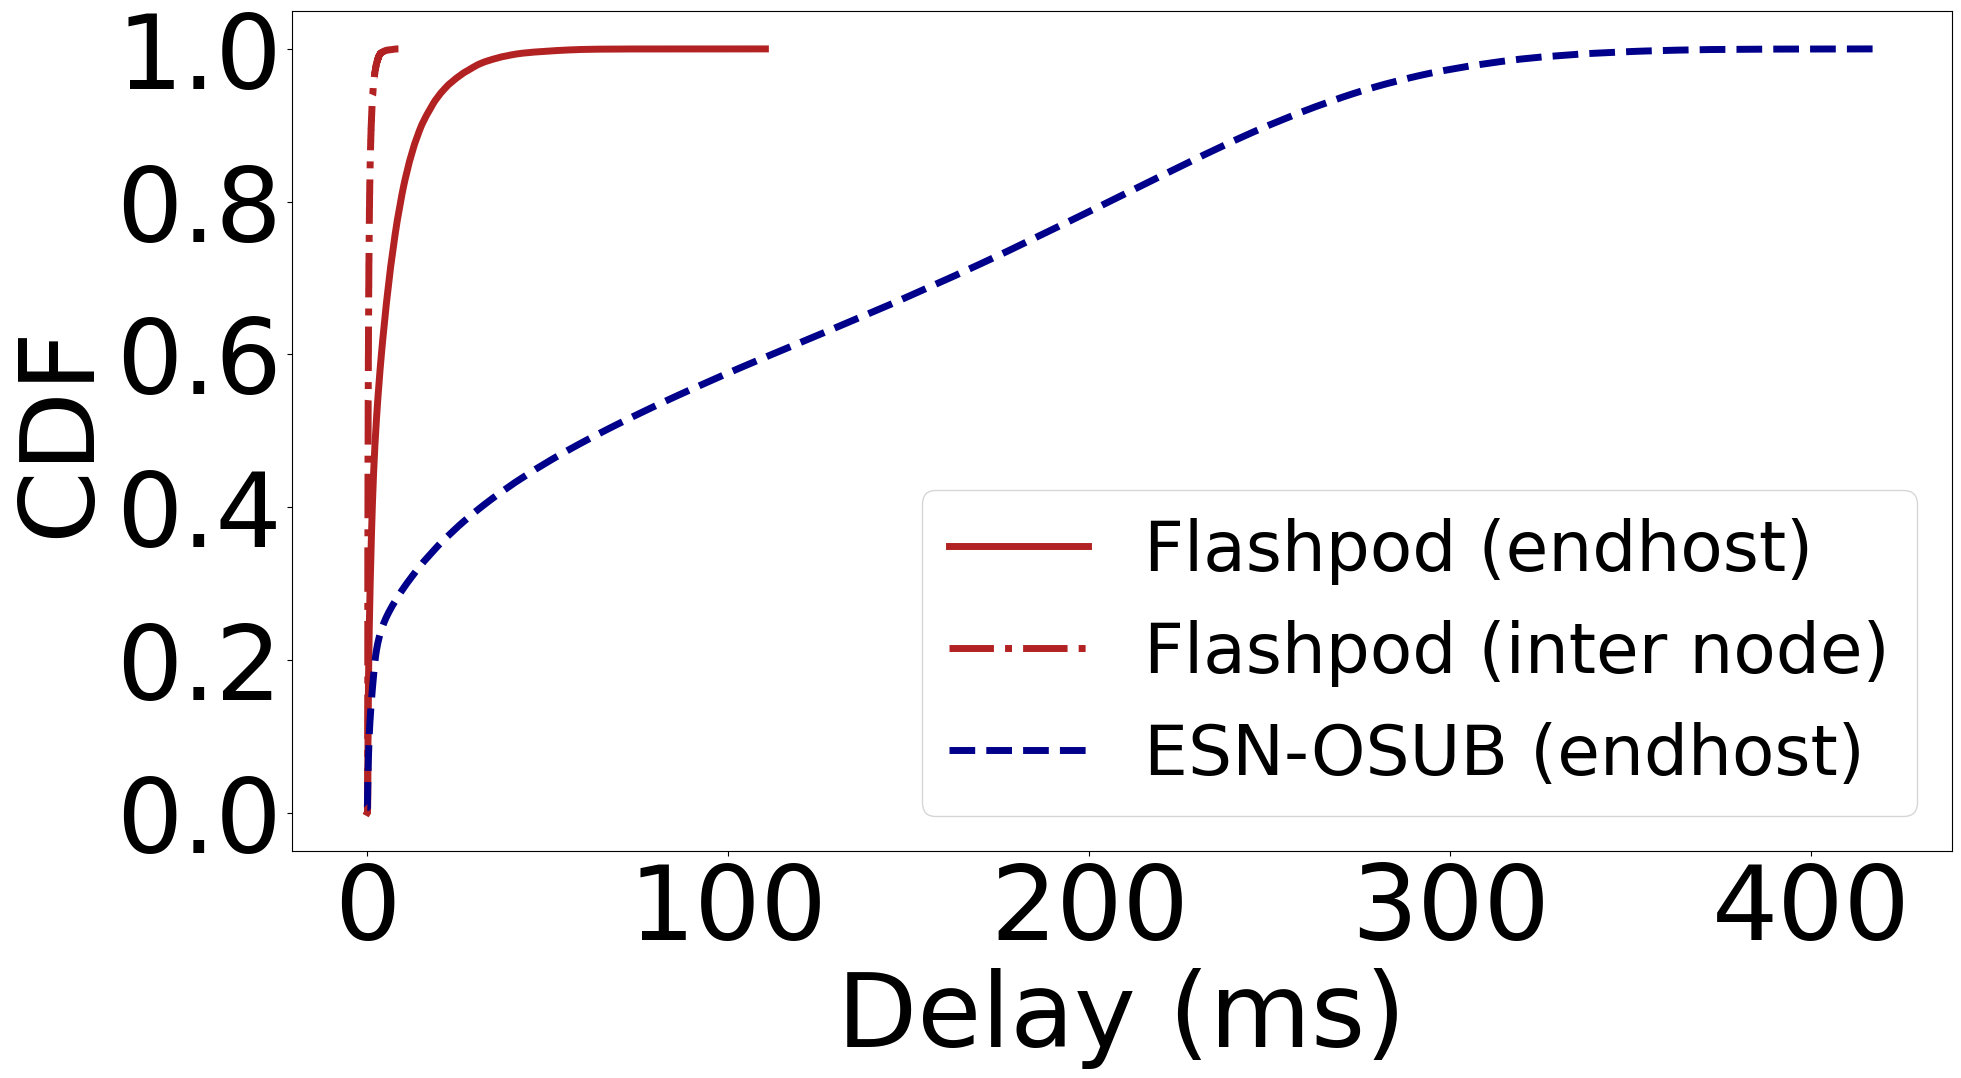

In [3]:
# filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
_,ax = plt.subplots(figsize=(20,12))
# filename = "../zeropod-singlepod/DATA/W5_incast_0.001/2x_recdelay_10_up_40/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
# src_packet_delay(filename)
filename1 = "../zeropod-multipods/DATA/W5_incast_0.001/2x_recdelay_10_up_40/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
# filename2 = "../dctcp/DATA/multipods/W5_incast_0.001/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
filename2 = "../zeropod-multipods/DATA/W5_incast_0.001/2x_recdelay_10_up_40/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
filename3 = "../ESN-OSUB/DATA/multipods/W5_incast_0.001/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"

# filename1 = "../dctcp-osub/DATA/singlepod/W5_incast_0.001/DATA_zeropod_W5_1/packet_network_delays_{}.txt"
# filename2 = "../dctcp/DATA/singlepod/W5_incast_0.001/DATA_zeropod_W5_1/packet_network_delays_{}.txt"
# filename2 = "../dctcp/DATA/singlepod/pureincast/DATA_zeropod_incast_130/packet_rough_delays_{}.txt"
src_packet_delay(filename1, filename2, filename3)
# core_packet_delay(filename)
# zeropod-singlepod/DATA/schedule4/optical-oobcp/2x_recdelay_10_up_40/DATA_zeropod_W5_0.5/packet_rough_delays_0.txt
# 画一条竖线
# plt.axvline(x=4, color='firebrick', linestyle='--', linewidth=3, label='Flashpod(2x)')
# plt.legend(loc="lower right", fontsize=20)
plt.savefig("../FIGS/microbenchmarks/source_packet_delay_multipods_load_1.pdf", bbox_inches="tight")

In [3]:
import numpy as np
from matplotlib import pyplot as plt

my_figsize = [10, 8]
my_fontsize = 30

NUM_BINS = 50000

num_buckets = 600000-1

loads = ['0.1', '0.25', '0.5', '0.75', '1']
loads = ['1']

colors = ["firebrick", "darkblue", "forestgreen", "royalblue", "darkorchid", "darkblue", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred", "darkorange", "darkgreen", "darkblue", "darkorchid", "darkcyan", "darkred"]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
def freq_array_to_cdf(freq_array):
    # 将频率数组转换为概率数组
    prob_array = freq_array / np.sum(freq_array)

    # 计算累积和
    cdf_array = np.cumsum(prob_array)

    return cdf_array

def find_last_nonzero(arr):
    for i in range(len(arr) - 1, 0, -1):
        if arr[i] > 0.1:
            return i
    return None

def load_and_draw(start, end, filename, iii, label):
    src_delays = np.zeros(num_buckets)
    for index in range(start, end):
            # draws/DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_0.1/packet_rough_delays_0.txt
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/packet_rough_delays_{0}.txt".format(index) 
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_TEST/packet_rough_delays_{0}.txt".format(index) 
        delay_filename=filename.format(index)
        tmp = np.loadtxt(delay_filename)
        src_delays += tmp[:num_buckets]
        # print(find_last_nonzero(tmp[:num_buckets]))
    # src_delays = np.trim_zeros(src_delays, 'b')
    np.set_printoptions(threshold=np.inf)
    last_non_zero = find_last_nonzero(src_delays)
    # print(last_non_zero)
    # print(src_delays[num_buckets-10:num_buckets])
    src_delays = src_delays[:last_non_zero]
    print("max SRC packet delay: ", len(src_delays), "us")
    # print(src_delays)
    cdf = freq_array_to_cdf(src_delays)        
    # plt.plot(np.arange(0, cdf[0:show_nums])/1e3, cdf[0:show_nums], linestyle='solid', linewidth=5, color = 'firebrick', label="load="+load)
    # plt.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)
    plt.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)

def load_and_pending_draw(start, end, filename, iii, label):
    src_delays = np.zeros(num_buckets)
    for index in range(start, end):
            # draws/DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_0.1/packet_rough_delays_0.txt
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/packet_rough_delays_{0}.txt".format(index) 
            # filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_TEST/packet_rough_delays_{0}.txt".format(index) 
        delay_filename=filename.format(index)
        tmp = np.loadtxt(delay_filename)
        src_delays += tmp[:num_buckets]
        # print(find_last_nonzero(tmp[:num_buckets]))
    # src_delays = np.trim_zeros(src_delays, 'b')
    np.set_printoptions(threshold=np.inf)
    last_non_zero = find_last_nonzero(src_delays)
    # print(last_non_zero)
    # print(src_delays[num_buckets-10:num_buckets])
    src_delays = src_delays[:last_non_zero]
    # 在src_delays最前面插入6个0，这是6us的传播时延
    src_delays = np.insert(src_delays, 0, np.zeros(6))
    print("max SRC packet delay: ", len(src_delays), "us")
    packets_inter_pod = np.sum(src_delays)
    packets_intra_pod = 4 * packets_inter_pod # 2 8 开
    src_delays[4] = packets_intra_pod
    
    # print(src_delays)
    cdf = freq_array_to_cdf(src_delays)        
    # plt.plot(np.arange(0, cdf[0:show_nums])/1e3, cdf[0:show_nums], linestyle='solid', linewidth=5, color = 'firebrick', label="load="+load)
    # plt.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)
    plt.plot(np.arange(0, len(cdf))/1e3, cdf, linestyle=linestyles[iii], linewidth=5, color=colors[iii], label=label)


def src_packet_delay(filename1, filename2):
    for i, load in enumerate(loads):
        # plt.subplots(figsize=(10, 8))
        # fct = np.loadtxt("../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/FCT.txt")
        
        # load_and_draw(0, 7, filename1, 0, "ESN-OSUB")
        if filename1 != '':
            load_and_pending_draw(10, 17, filename1, 0, "Flashpod(2x)")
        if filename2 != '':
            load_and_draw(0, 7, filename2, 1, "ESN-OSUB")
        # load_and_draw(3, 5, filename, 2, "100KB~10MB")
        # load_and_draw(5, 7, filename, 3, "> 10MB")
        
        plt.xlabel("Delay (ms)", fontsize=my_fontsize)
        plt.ylabel("CDF", fontsize=my_fontsize)
        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)
        # plt.xlim(0, 0.)
        plt.legend(loc="lower right", fontsize=20)
        # plt.xscale('log')
        plt.title("Source Packet Delay", fontsize=my_fontsize)
        plt.title("Network Delay", fontsize=my_fontsize)

def core_packet_delay(filename):
    for i, load in enumerate(loads):
        plt.subplots(figsize=(10, 8))
        # fct = np.loadtxt("../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_" + load + "/FCT.txt")
        src_delays = np.zeros(num_buckets)
        load_and_draw(10, 13, filename, 1, "< 100KB", )
        load_and_draw(13, 15, filename, 2, "100KB~10MB")
        load_and_draw(15, 17, filename, 3, "> 10MB")
        
        plt.xlabel("Delay (ms)", fontsize=my_fontsize)
        plt.ylabel("CDF", fontsize=my_fontsize)
        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)
        # plt.xlim(0, 0.5)
        plt.xscale('log')
        plt.legend(loc="upper left", fontsize=20)
        plt.title("Core Packet Delay", fontsize=my_fontsize)


max SRC packet delay:  10251 us
max SRC packet delay:  160 us


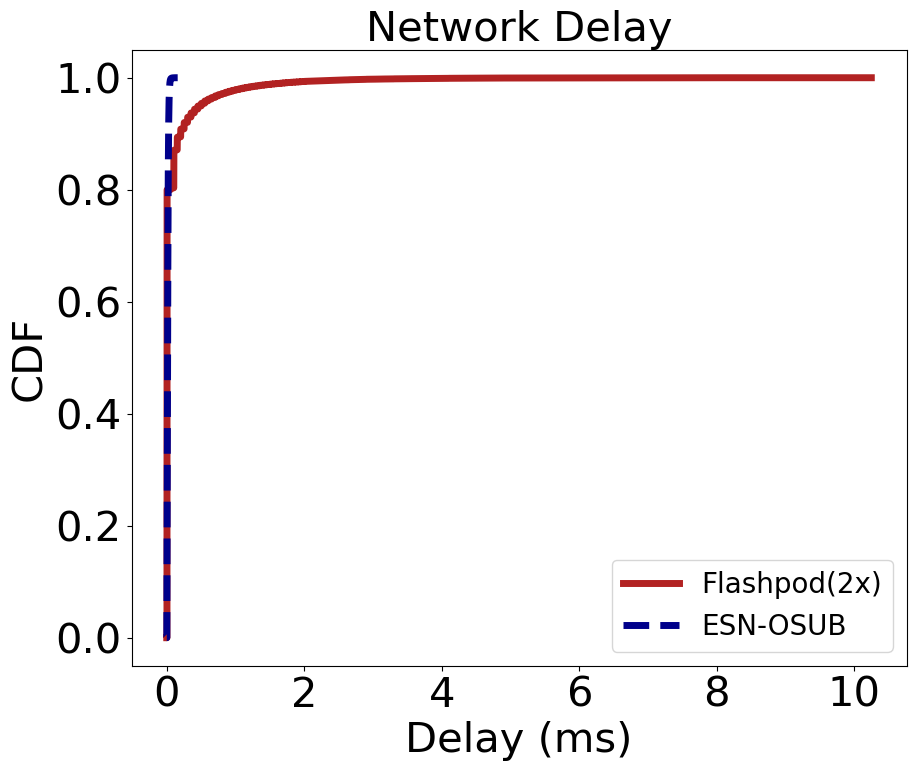

In [4]:
# filename = "../DATA/Zeropod/Zeropod/multipods_W5/optical-oobcp/2x_recdelay_10_up_40_delay_buffer/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
plt.subplots(figsize=(10, 8))
# filename = "../zeropod-singlepod/DATA/W5_incast_0.001/2x_recdelay_10_up_40/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
# src_packet_delay(filename)
filename1 = "../zeropod-multipods/DATA/W5_incast_0.001/2x_recdelay_10_up_40/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"
# filename2 = "../dctcp-osub/DATA/singlepod/W5_incast_0.001/DATA_zeropod_W5_1/packet_rough_delays_{}.txt"

filename2 = "../dctcp-osub/DATA/multipods/W5_incast_0.001/DATA_zeropod_W5_1/packet_network_delays_{}.txt"
# filename2 = "../dctcp/DATA/singlepod/W5_incast_0.001/DATA_zeropod_W5_1/packet_network_delays_{}.txt"
# filename2 = "../dctcp/DATA/singlepod/pureincast/DATA_zeropod_incast_130/packet_rough_delays_{}.txt"
src_packet_delay(filename1, filename2)
# core_packet_delay(filename)
# zeropod-singlepod/DATA/schedule4/optical-oobcp/2x_recdelay_10_up_40/DATA_zeropod_W5_0.5/packet_rough_delays_0.txt
# 画一条竖线
# plt.axvline(x=4, color='firebrick', linestyle='--', linewidth=3, label='Flashpod(2x)')
# plt.legend(loc="lower right", fontsize=20)